In [109]:
import mne
from mne.preprocessing import ICA
import matplotlib.pyplot as plt
import numpy as np
import scipy as sc
from scipy.signal import convolve
from scipy.ndimage import convolve1d
import seaborn as sns

In [47]:
subject1 = sc.io.loadmat("../data/s1.mat")
data1 = subject1['eeg']
data1 = data1.transpose(0,3,1,2)
print(np.shape(data1)) #(freq x trials x channels x points)

(12, 15, 8, 1114)


In [48]:
srate = 256
stim_freq = [9.25, 11.25, 13.25, 9.75, 11.75, 13.75, 10.25, 12.25, 14.25, 10.75, 12.75, 14.75]
stim_onset = 0.15
stim_onset_idx = 39

n_channels = 8
n_trials = 15
n_targets = 12
n_points = 1114

t_min = 0.15
t_max = 4
f_min = 6
f_max = 60

Signal Preprocessing step

In [49]:
iir_filter = dict(order=4, ftype='butter')
subject1data : list[mne.EpochsArray] = []

for i in range(n_targets):
    subject1data.append(
        mne.EpochsArray(
            data=data1[i,:,:,:],
            info = mne.create_info(n_channels, srate, ch_types='eeg'),
            verbose = False
        ).filter(l_freq = f_min, h_freq = f_max, method='iir', iir_params = iir_filter, verbose = True)
    )

Setting up band-pass filter from 6 - 60 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 6.00, 60.00 Hz: -6.02, -6.02 dB

Setting up band-pass filter from 6 - 60 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 6.00, 60.00 Hz: -6.02, -6.02 dB

Setting up band-pass filter from 6 - 60 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 6.00, 60.00 Hz: -6.02, -6.02 dB

Setting up band-pass filter from 6 - 60 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (e

Text(0, 0.5, 'Amplitude (microV)')

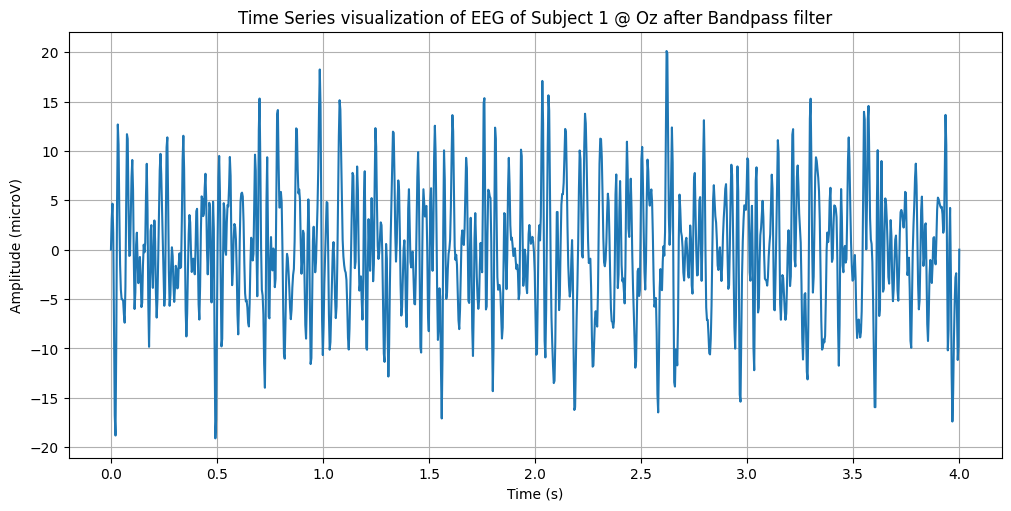

In [82]:
fig, ax = plt.subplots(figsize= (10,5), sharex=True, sharey=True, layout="constrained")
ax.plot(np.linspace(0, 4, 1114),subject1data[1].get_data()[1,7,:])
ax.grid(True)
ax.set_title("Time Series visualization of EEG of Subject 1 @ Oz after Bandpass filter")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude (microV)")

CCA Preprocessing

In [ ]:
time_series_mean = []
for target_data in subject1data:
    time_series_mean.append(np.mean(target_data.get_data(), 2))

print(np.mean(time_series_mean)) #is around 0, so i hope we dont have to center it :)

0.0245387002876535


Generating Refernece matrix (freq x sin/cos row x harmonics x freq)

In [ ]:
harmonics = np.arange(1,4)
times = np.linspace(t_min, t_max, n_points)

Y = np.zeros([n_targets 2*len(harmonics), n_points])
for k, freq in enumerate(stim_freq):
    Y[k,:,:] = [[[np.sin(2*np.pi*h*freq*time) for time in times] for h in harmonics] + [[np.cos(2*np.pi*h*freq*time) for time in times] for h in harmonics]]

print(np.shape(Y))

(12, 1, 6, 1114)


Computing Covaraiance Matrices

In [ ]:
C_XX = [
    (data.get_data() @ data.get_data().transpose(0,2,1))/n_points for data in subject1data
] # Channel x Channel Covariance matrix (Auto Covariance on EEG

C_YY = [
    np.shape(data) for data in Y
]

print(C_YY)

Visualizing Covariance Matrices

In [ ]:
row = 12
col = 15

fig, axes = plt.subplots(row, col, figsize = (1.25*row, 1.25*col), layout = "constrained", sharex = True, sharey = True)
for t in range(row):
    for tr in range(col):
        sns.heatmap(C_XX[t][tr], cmap ='viridis', ax = axes[t][tr], cbar=False)
        axes[t][tr].set_title(f"{stim_freq[t]}, {tr}")